# **Joseph Benedict Sy**

# **2ECE-C**

In [8]:
import pandas as pd

In [9]:
import matplotlib.pyplot as plt

In [10]:
df = pd.read_excel('board2.xlsx')
df

,Name,Gender,Track,Hometown,Math,Electronics,GEAS,Communication
0,S1,Male,Instrumentation,Luzon,58,89,75,78
1,S2,Female,Communication,Mindanao,52,75,90,52
2,S3,Female,Instrumentation,Mindanao,83,74,77,57
3,S4,Male,Instrumentation,Visayas,65,58,91,68
4,S5,Male,Communication,Luzon,59,86,43,88
5,S6,Female,Microelectronics,Visayas,88,45,86,83
6,S7,Female,Instrumentation,Luzon,66,60,60,48
7,S8,Male,Instrumentation,Luzon,49,81,64,53
8,S9,Male,Instrumentation,Luzon,50,36,63,42
9,S10,Male,Microelectronics,Mindanao,80,84,61,44


In [11]:
df.describe()

,Math,Electronics,GEAS,Communication
count,30.000000,30.00000,30.000000,30.000000
mean,72.166667,61.60000,71.866667,61.966667
std,12.660237,17.29381,15.725519,15.376837
min,48.000000,35.00000,40.000000,41.000000
25%,64.250000,47.00000,61.250000,49.000000
50%,73.500000,60.00000,76.000000,60.000000
75%,83.000000,76.50000,83.750000,72.750000
max,89.000000,91.00000,94.000000,88.000000


### **A. Visayas Communication DataFrame**

In [12]:
# Calculate Average first on a temporary dataframe copy to keep the original df intact
temp_df = df.copy()
temp_df['Average'] = temp_df[['Math', 'Electronics', 'GEAS', 'Communication']].mean(axis=1)

In [13]:
# Apply explicit conditions for Hometown and Track
VisComm = temp_df[(temp_df['Hometown'] == 'Visayas') & (temp_df['Track'] == 'Communication')]

In [14]:
# Select and reorder columns correctly
VisComm = VisComm[['Name', 'Gender', 'Math', 'Electronics', 'Average']]

In [15]:
# Display the DataFrame and its row count
print(f"Number of rows: {len(VisComm)}")
VisComm

Number of rows: 5


,Name,Gender,Math,Electronics,Average
10,S11,Female,48,56,54.75
11,S12,Male,89,67,76.00
17,S18,Male,81,40,63.50
21,S22,Female,64,39,62.50
27,S28,Male,85,53,67.75


### **B. Visayas Female DataFrame**

In [16]:
# Calculate Average first on a temporary dataframe copy to keep the original df intact
temp_df = df.copy()
temp_df['Average'] = temp_df[['Math', 'Electronics', 'GEAS', 'Communication']].mean(axis=1)

# Filter for students whose Hometown is Visayas and Gender is Female
VisFemale = temp_df[(temp_df['Hometown'] == 'Visayas') & (temp_df['Gender'] == 'Female')]

In [17]:
# Filter for students whose Hometown is Visayas and Gender is Female
VisFemale = temp_df[(temp_df['Hometown'] == 'Visayas') & (temp_df['Gender'] == 'Female')]

In [18]:
# Retain only: Name, Track, GEAS, Electronics, Average
VisFemale = VisFemale[['Name', 'Track', 'GEAS', 'Electronics', 'Average']]

In [19]:
# Display the entire VisFemale DataFrame
print("Complete VisFemale DataFrame:")
VisFemale

Complete VisFemale DataFrame:


,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,75.50
10,S11,Communication,48,56,54.75
20,S21,Microelectronics,68,51,68.50
21,S22,Communication,89,39,62.50
23,S24,Microelectronics,60,45,57.75
25,S26,Instrumentation,83,47,65.75


In [20]:
# Filter and display students whose Average is at least 60 without overwriting VisFemale
print("\nStudents with Average >= 60:")
VisFemale[VisFemale['Average'] >= 60.0]


Students with Average >= 60:


,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,75.50
20,S21,Microelectronics,68,51,68.50
21,S22,Communication,89,39,62.50
25,S26,Instrumentation,83,47,65.75


Mean Average by Track:
Track
Communication       67.975
Instrumentation     65.225
Microelectronics    67.500
Name: Average, dtype: float64

Mean Average by Gender:
Gender
Female    66.616667
Male      67.183333
Name: Average, dtype: float64

Mean Average by Hometown:
Hometown
Luzon       68.083333
Mindanao    66.678571
Visayas     65.750000
Name: Average, dtype: float64


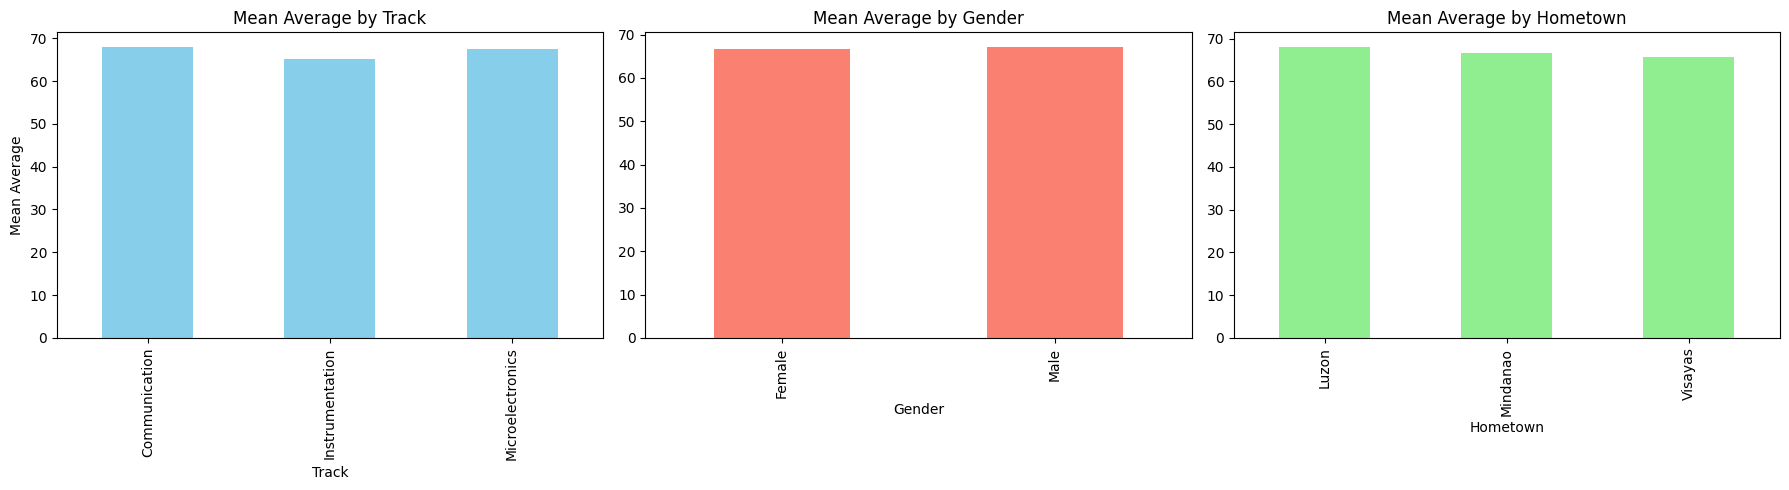

The Microelectronics track has the highest sample mean among tracks (Communication).
The Male gender has the highest sample mean.
Students from Luzon have the highest sample mean among hometowns.


In [21]:
# Ensure temp_df has the Average column
temp_df = df.copy()
temp_df['Average'] = temp_df[['Math', 'Electronics', 'GEAS', 'Communication']].mean(axis=1)

# a. & b. Compute and display mean of Average for each category
track_avg = temp_df.groupby('Track')['Average'].mean()
gender_avg = temp_df.groupby('Gender')['Average'].mean()
hometown_avg = temp_df.groupby('Hometown')['Average'].mean()

print("Mean Average by Track:")
print(track_avg)
print("\nMean Average by Gender:")
print(gender_avg)
print("\nMean Average by Hometown:")
print(hometown_avg)

# c. Create one figure containing three bar charts
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

track_avg.plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Mean Average by Track')
axes[0].set_ylabel('Mean Average')

gender_avg.plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('Mean Average by Gender')

hometown_avg.plot(kind='bar', ax=axes[2], color='lightgreen')
axes[2].set_title('Mean Average by Hometown')

plt.tight_layout()
plt.show()

# d. Concise statements identifying the category with the highest sample mean
print(f"The Microelectronics track has the highest sample mean among tracks ({track_avg.idxmax()}).")
print(f"The {gender_avg.idxmax()} gender has the highest sample mean.")
print(f"Students from {hometown_avg.idxmax()} have the highest sample mean among hometowns.")